In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task A - Data Pre-Processing

In [2]:
df_txn_data = pd.read_csv('/content/sample_data/transactions_data.csv')

In [3]:
df_txn_data.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475509,2010-01-01 04:45:00,1718,4706,$46.21,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN
1,7475582,2010-01-01 06:03:00,511,974,$3.33,Swipe Transaction,20519,Phoenix,AZ,85015.0,5942,NaN
2,7475752,2010-01-01 06:52:00,1718,2029,$10.60,Swipe Transaction,20519,Spring Valley,CA,91977.0,5942,NaN
3,7475819,2010-01-01 07:08:00,511,1038,$21.50,Swipe Transaction,79038,Phoenix,AZ,85015.0,7538,NaN
4,7475828,2010-01-01 07:09:00,1094,3755,$80.00,Swipe Transaction,27092,Boyne City,MI,49712.0,4829,NaN


### 1. Ensure Numeric values for core continuous columns. If not numeric then convert them into appropriate int and float datatypes.

### 2. Check Data Hygiene throughout the data e.g. Turn “amount” column ```(with $ signs)``` into a clean number column. “$46.26” ---🡪 46.26

In [4]:
df_txn_data['amount'] = df_txn_data['amount'].str.replace('$', '').astype(float)

In [5]:
df_txn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50000 non-null  int64  
 1   date            50000 non-null  object 
 2   client_id       50000 non-null  int64  
 3   card_id         50000 non-null  int64  
 4   amount          50000 non-null  float64
 5   use_chip        50000 non-null  object 
 6   merchant_id     50000 non-null  int64  
 7   merchant_city   50000 non-null  object 
 8   merchant_state  41992 non-null  object 
 9   zip             41642 non-null  float64
 10  mcc             50000 non-null  int64  
 11  errors          855 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 4.6+ MB


In [6]:
df_card_data = pd.read_csv('/content/sample_data/cards_data.csv')

In [7]:
df_card_data.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [8]:
df_card_data['credit_limit'] = df_card_data['credit_limit'].str.replace('$', '').astype(float)

In [9]:
df_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     75 non-null     int64  
 1   client_id              75 non-null     int64  
 2   card_brand             75 non-null     object 
 3   card_type              75 non-null     object 
 4   card_number            75 non-null     int64  
 5   expires                75 non-null     object 
 6   cvv                    75 non-null     int64  
 7   has_chip               75 non-null     object 
 8   num_cards_issued       75 non-null     int64  
 9   credit_limit           75 non-null     float64
 10  acct_open_date         75 non-null     object 
 11  year_pin_last_changed  75 non-null     int64  
 12  card_on_dark_web       75 non-null     object 
dtypes: float64(1), int64(6), object(6)
memory usage: 7.7+ KB


In [10]:
df_user = pd.read_csv('/content/sample_data/users_data.csv')

In [11]:
df_user.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [12]:
data_set_amt = [
    ('per_capita_income', df_user),
    ('yearly_income', df_user),
    ('total_debt', df_user)
]
for name, dataset in data_set_amt:
    dataset[name] = dataset[name].str.replace('$', '').astype(float)

In [13]:
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 25 non-null     int64  
 1   current_age        25 non-null     int64  
 2   retirement_age     25 non-null     int64  
 3   birth_year         25 non-null     int64  
 4   birth_month        25 non-null     int64  
 5   gender             25 non-null     object 
 6   address            25 non-null     object 
 7   latitude           25 non-null     float64
 8   longitude          25 non-null     float64
 9   per_capita_income  25 non-null     float64
 10  yearly_income      25 non-null     float64
 11  total_debt         25 non-null     float64
 12  credit_score       25 non-null     int64  
 13  num_credit_cards   25 non-null     int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 2.9+ KB


### 3. Check how many duplicate rows are there, handle them.

In [14]:
df_txn_data.duplicated().sum()

np.int64(0)

In [15]:
df_card_data.duplicated().sum()

np.int64(0)

In [16]:
df_user.duplicated().sum()

np.int64(0)

### 4. Display number and columns having missing values. Also visualize and then finally handle them with appropriate action.

In [17]:
df_card_data.isnull().sum()

,0
id,0
client_id,0
card_brand,0
card_type,0
card_number,0
expires,0
cvv,0
has_chip,0
num_cards_issued,0
credit_limit,0


In [18]:
df_txn_data.isnull().sum()

,0
id,0
date,0
client_id,0
card_id,0
amount,0
use_chip,0
merchant_id,0
merchant_city,0
merchant_state,8008
zip,8358


In [19]:
df_user.isnull().sum()

,0
id,0
current_age,0
retirement_age,0
birth_year,0
birth_month,0
gender,0
address,0
latitude,0
longitude,0
per_capita_income,0


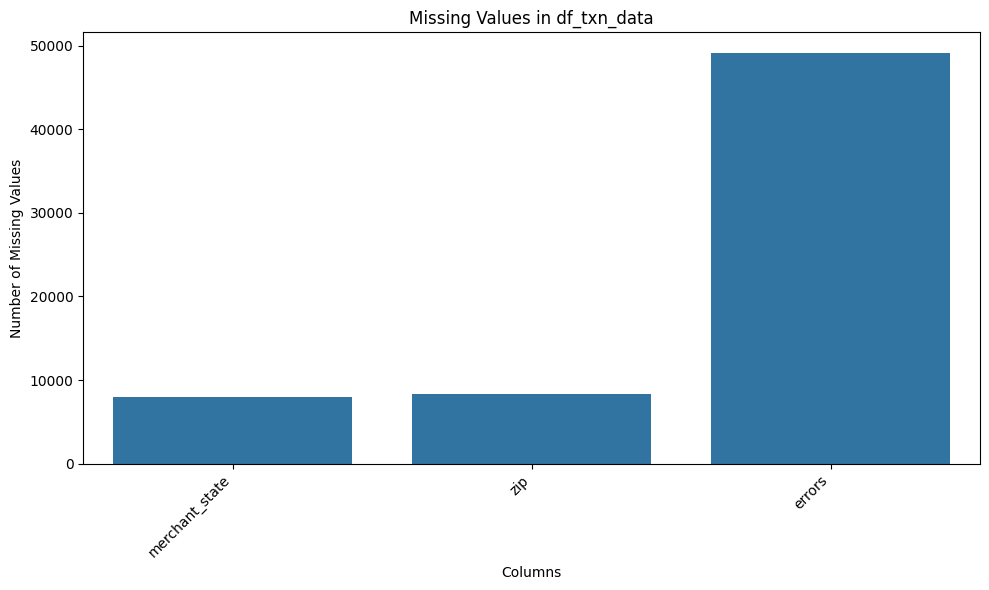

In [20]:
missing_values_txn = df_txn_data.isnull().sum()
missing_values_txn = missing_values_txn[missing_values_txn > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values_txn.index, y=missing_values_txn.values)
plt.title('Missing Values in df_txn_data')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df_txn_data['errors'] = df_txn_data['errors'].fillna('No Error')

In [22]:
df_txn_data.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475509,2010-01-01 04:45:00,1718,4706,46.21,Online Transaction,15143,ONLINE,NaN,NaN,4784,No Error
1,7475582,2010-01-01 06:03:00,511,974,3.33,Swipe Transaction,20519,Phoenix,AZ,85015.0,5942,No Error
2,7475752,2010-01-01 06:52:00,1718,2029,10.60,Swipe Transaction,20519,Spring Valley,CA,91977.0,5942,No Error
3,7475819,2010-01-01 07:08:00,511,1038,21.50,Swipe Transaction,79038,Phoenix,AZ,85015.0,7538,No Error
4,7475828,2010-01-01 07:09:00,1094,3755,80.00,Swipe Transaction,27092,Boyne City,MI,49712.0,4829,No Error


In [23]:
df_txn_data['errors'].isnull().sum()

np.int64(0)

In [24]:
df_txn_data['merchant_state'] = df_txn_data['merchant_state'].fillna('Unknown')
df_txn_data['zip'] = df_txn_data['zip'].fillna(0)

In [25]:
df_txn_data[['merchant_state', 'zip']].isnull().sum()

,0
merchant_state,0
zip,0


### 5. Convert the use_chip column to have only three values: swipe, chip, or online.

In [26]:
df_txn_data['use_chip'].value_counts()

,count
use_chip,
Swipe Transaction,41992
Online Transaction,8008


### 6. How can you clean up city names, so they don’t have extra spaces and always start with capital letters?

In [27]:
df_txn_data['merchant_city'] = df_txn_data['merchant_city'].str.replace(' ', '').str.capitalize()

In [28]:
df_txn_data['merchant_city']

,merchant_city
0,Online
1,Phoenix
2,Springvalley
3,Phoenix
4,Boynecity
...,...
49995,Losangeles
49996,Westcovina
49997,Page
49998,Warrington


# 7. Make sure state codes are always two capital letters (like CA, NY)? --> PENDING

In [29]:
df_txn_data['merchant_state'].unique()

array(['Unknown', 'AZ', 'CA', 'MI', 'KY', 'LA', 'OK', 'PA', 'NY', 'WI',
       'IA', 'OH', 'AR', 'NV', 'Canada', 'NJ', 'IN', 'WV', 'FL', 'TX',
       'NM', 'IL', 'AK', 'TN', 'HI', 'Sierra Leone', 'Mexico', 'Haiti',
       'AL', 'MD', 'Guatemala', 'MO', 'VT', 'CT', 'VA', 'MN', 'ME', 'GA',
       'Colombia', 'WA', 'SC', 'Peru', 'France', 'Sweden', 'RI', 'MA',
       'NC', 'OR', 'MS', 'China', 'KS', 'WY', 'ID', 'South Korea',
       'Indonesia', 'Denmark', 'CO', 'Japan', 'United Kingdom',
       'Portugal', 'Jamaica', 'Hong Kong', 'MT', 'DE'], dtype=object)

### 8. How do you turn ZIP codes into a proper 5-digit string, keeping leading zeros?

In [30]:
df_txn_data['zip'] = df_txn_data['zip'].apply(lambda x: f"{int(x):05d}")

In [31]:
df_txn_data['zip']

,zip
0,00000
1,85015
2,91977
3,85015
4,49712
...,...
49995,90005
49996,91792
49997,86040
49998,18976


### TASK - B

### 1. Customer Card Profile:

• Explore the user matrix across card_brand, card_type and credit_limit.

In [32]:
card_matrix = df_card_data.groupby(['card_type', 'card_brand'])['credit_limit'].describe().reset_index()
display(card_matrix)

,card_type,card_brand,count,mean,std,min,25%,50%,75%,max
0,Credit,Amex,1.0,8800.000000,NaN,8800.0,8800.0,8800.0,8800.00,8800.0
1,Credit,Discover,3.0,11933.333333,7626.488926,4700.0,7950.0,11200.0,15550.00,19900.0
2,Credit,Mastercard,4.0,9850.000000,2693.820088,6000.0,9075.0,10650.0,11425.00,12100.0
3,Credit,Visa,14.0,17800.000000,23847.593009,5600.0,7525.0,11150.0,15700.00,98100.0
4,Debit,Mastercard,27.0,21422.703704,13970.198666,4147.0,11970.0,20291.0,26748.00,77237.0
5,Debit,Visa,20.0,33148.150000,36319.856724,620.0,15488.5,23131.5,31620.25,132439.0
6,Debit (Prepaid),Mastercard,5.0,63.200000,25.994230,28.0,54.0,62.0,73.00,99.0
7,Debit (Prepaid),Visa,1.0,76.000000,NaN,76.0,76.0,76.0,76.00,76.0


# • Visualize using appropriate graphs for them.

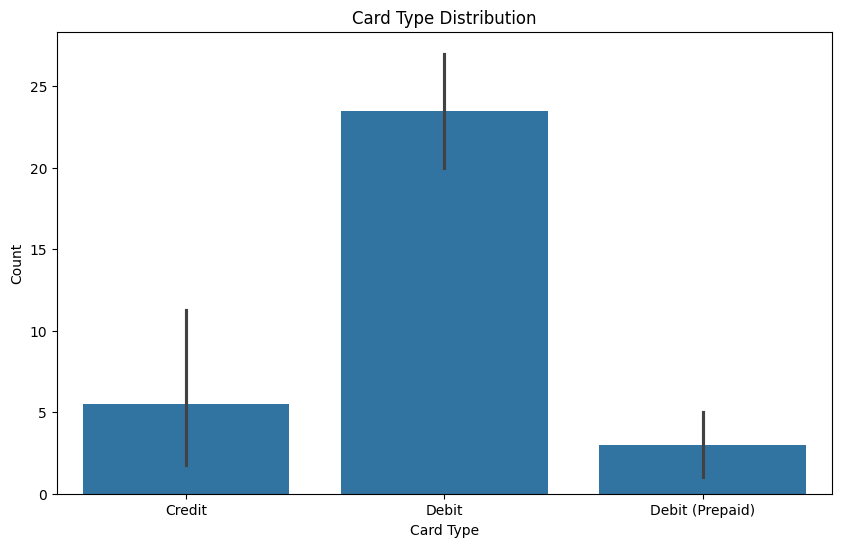

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='card_type', y='count', data=card_matrix)
plt.title('Card Type Distribution')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.show()

# 2. Explore Transactions:

• What is the time frame of the data collected. --> PENDING

• Which client has spent the most amount.

In [34]:
df_txn_data.groupby('client_id')['amount'].sum().sort_values(ascending=False).head(1)

,amount
client_id,
708,326179.31


# • Highest and lowest transactions amounts spent

In [35]:
df_txn_data['amount'].max()

6820.2

In [36]:
df_txn_data['amount'].min()

-500.0

# • Transactions amounts within use_chip category

In [37]:
df_txn_data.groupby('use_chip')['amount'].sum()

,amount
use_chip,
Online Transaction,438554.98
Swipe Transaction,2143438.74


### GRAPHS are Pending For TASK B Point#2

### 3. Customer Spend Profile vs. Credit Health
  
  • For each client_id, compute: total spend, average ticket size, transaction count, and monthly frequency.

  • Create a dataframe for credit_score, yearly_income, total_debt, num_credit_cards.
  
  • Visualize their co-operation.
  
  • Plot Scatter of average amount spent vs yearly_income.

### For each client_id. compute: total spend average ticket size, transaction count, and monthly frequency.

In [39]:
df_user_few_colmns = df_user[['credit_score', 'yearly_income', 'total_debt', 'num_credit_cards']]

## Compute Spend Profile Metrics

### Subtask:
For each `client_id` in `df_txn_data`, compute the total spend (sum of `amount`), transaction count (number of transactions), and average ticket size (total spend / transaction count). Also, calculate the monthly transaction frequency.


**Reasoning**:
The first step is to convert the 'date' column in `df_txn_data` to datetime objects to facilitate time-based calculations as per the instructions.



In [40]:
client_spend_profile = df_txn_data.groupby('client_id').agg(
    total_spend=('amount', 'sum'),
    transaction_count=('amount', 'count')
).reset_index()
client_spend_profile['average_ticket_size'] = client_spend_profile['total_spend'] / client_spend_profile['transaction_count']
print("Client Spend Profile (head):")
display(client_spend_profile.head())

Client Spend Profile (head):


,client_id,total_spend,transaction_count,average_ticket_size
0,68,202013.82,3538,57.098310
1,153,70806.08,1277,55.447204
2,511,285794.61,6548,43.646092
3,708,326179.31,2454,132.917404
4,825,259484.68,3200,81.088962


**Reasoning**:
To calculate the monthly transaction frequency, I will first create a 'year_month' column from the 'date' column in `df_txn_data`, then group by 'client_id' and 'year_month' to count monthly transactions, and finally, calculate the mean of these monthly counts per client.



In [44]:
df_txn_data['date'] = pd.to_datetime(df_txn_data['date'])
df_txn_data['year_month'] = df_txn_data['date'].dt.to_period('M')
monthly_transactions = df_txn_data.groupby(['client_id', 'year_month']).size().reset_index(name='monthly_count')
monthly_frequency = monthly_transactions.groupby('client_id')['monthly_count'].mean().reset_index(name='monthly_frequency')

client_spend_profile = pd.merge(client_spend_profile, monthly_frequency, on='client_id', how='left')


**Reasoning**:
The previous attempt to create a DataFrame with specific user credit health columns resulted in a KeyError because of incorrect indexing syntax. This step corrects the syntax to select multiple columns from `df_user` to create `df_user_credit_health` as specified in the subtask.



In [45]:
client_spend_profile.head()

,client_id,total_spend,transaction_count,average_ticket_size,monthly_frequency_x,monthly_frequency_y
0,68,202013.82,3538,57.098310,104.058824,104.058824
1,153,70806.08,1277,55.447204,37.558824,37.558824
2,511,285794.61,6548,43.646092,192.588235,192.588235
3,708,326179.31,2454,132.917404,72.176471,72.176471
4,825,259484.68,3200,81.088962,94.117647,94.117647


In [47]:
df_user_credit_health = df_user[['credit_score', 'yearly_income', 'total_debt', 'num_credit_cards']]

In [48]:
df_user_credit_health.head()

,credit_score,yearly_income,total_debt,num_credit_cards
0,787,59696.0,127613.0,5
1,701,77254.0,191349.0,5
2,698,33483.0,196.0,5
3,722,249925.0,202328.0,4
4,675,109687.0,183855.0,1


### Visualize their cooperation

## Visualize their co-operation

To visualize the cooperation between the client spend profile and credit health data, I will display the head of the `merged_df`, which contains both sets of information combined for each client.

In [51]:
df_user_renamed = df_user.rename(columns={'id': 'client_id'})
merged_df = pd.merge(client_spend_profile, df_user_renamed, on='client_id', how='inner')
print("Merged DataFrame recreated. Displaying head:")
display(merged_df.head())

Merged DataFrame recreated. Displaying head:


,client_id,total_spend,transaction_count,average_ticket_size,monthly_frequency_x,monthly_frequency_y,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,68,202013.82,3538,57.098310,104.058824,104.058824,42,70,1977,10,Male,58 Birch Lane,41.55,-90.60,20599.0,41997.0,0.0,704,3
1,153,70806.08,1277,55.447204,37.558824,37.558824,76,71,1943,8,Female,172 Birch Street,35.29,-111.32,21950.0,27484.0,16803.0,660,4
2,511,285794.61,6548,43.646092,192.588235,192.588235,66,68,1953,10,Male,153 Tenth Lane,32.21,-110.88,17460.0,35602.0,55369.0,661,5
3,708,326179.31,2454,132.917404,72.176471,72.176471,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,825,259484.68,3200,81.088962,94.117647,94.117647,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5


## Visualize their Co-operation (Correlation Matrix)

To understand the relationships between the client's spending behavior and their credit health, I will compute the correlation matrix for the relevant numerical columns in the `merged_df`. This provides a quantitative 'visualization' of their cooperation without needing a graphical plot.

In [52]:
correlation_columns = [
    'total_spend',
    'average_ticket_size',
    'monthly_frequency_x', # Using one of the monthly frequency columns
    'credit_score',
    'yearly_income',
    'total_debt',
    'num_credit_cards'
]

# Calculate the correlation matrix
correlation_matrix = merged_df[correlation_columns].corr()

print("Correlation Matrix of Spend Profile vs. Credit Health:")
display(correlation_matrix)

print("\nNote: The column 'monthly_frequency_x' is used for monthly frequency. There were two such columns due to merge, but they contain identical values.")

Correlation Matrix of Spend Profile vs. Credit Health:


,total_spend,average_ticket_size,monthly_frequency_x,credit_score,yearly_income,total_debt,num_credit_cards
total_spend,1.000000,0.635766,0.527370,0.021342,0.541089,0.363692,0.251800
average_ticket_size,0.635766,1.000000,-0.276390,-0.016571,0.856931,0.733904,0.096460
monthly_frequency_x,0.527370,-0.276390,1.000000,0.007086,-0.170930,-0.210101,0.165665
credit_score,0.021342,-0.016571,0.007086,1.000000,0.017624,0.044961,-0.040426
yearly_income,0.541089,0.856931,-0.170930,0.017624,1.000000,0.739717,-0.046947
total_debt,0.363692,0.733904,-0.210101,0.044961,0.739717,1.000000,-0.134116
num_credit_cards,0.251800,0.096460,0.165665,-0.040426,-0.046947,-0.134116,1.000000



Note: The column 'monthly_frequency_x' is used for monthly frequency. There were two such columns due to merge, but they contain identical values.


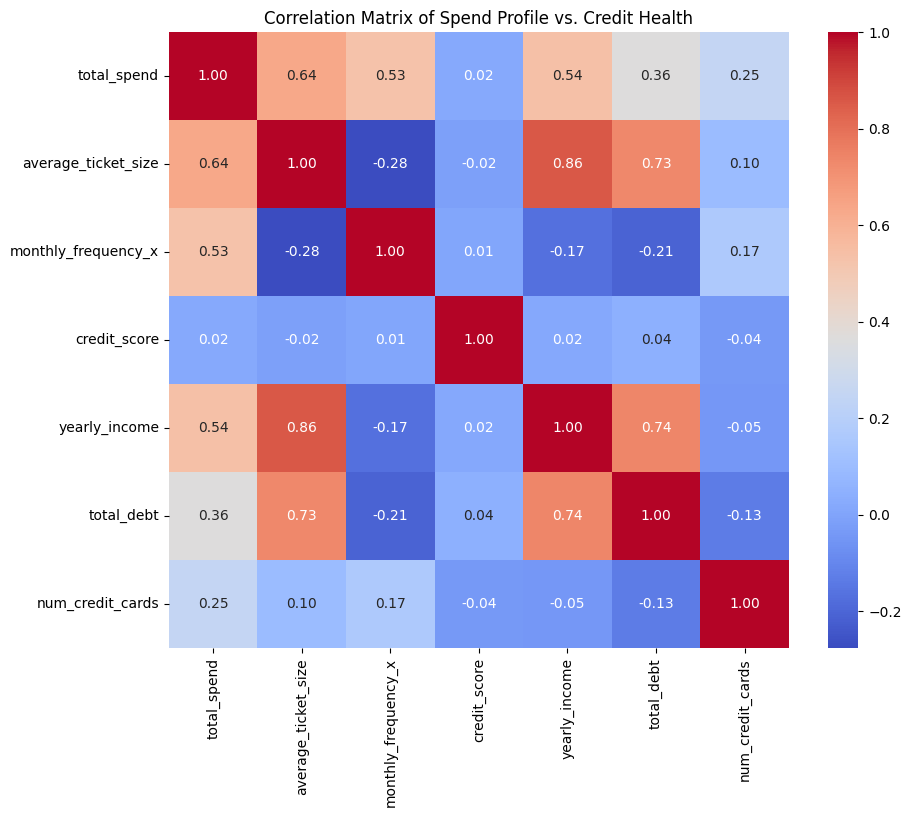

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Spend Profile vs. Credit Health')
plt.show()

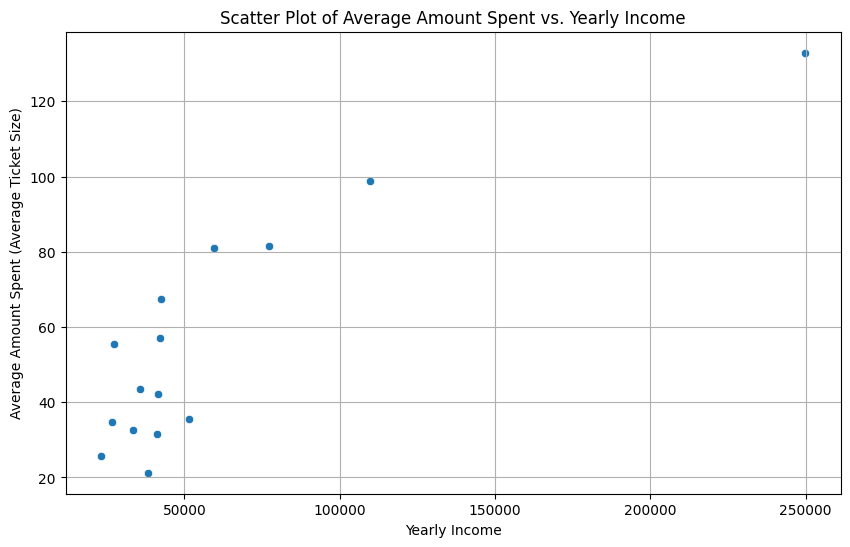

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='yearly_income', y='average_ticket_size', data=merged_df)
plt.title('Scatter Plot of Average Amount Spent vs. Yearly Income')
plt.xlabel('Yearly Income')
plt.ylabel('Average Amount Spent (Average Ticket Size)')
plt.grid(True)
plt.show()